# CAP 4105 — Bonus Homework: Neural Networks

**Due**: April 17, 2026, 11:59 PM via Canvas  
**Points**: 5 bonus points (added directly to your final course grade)  
**Individual work only**

---

## Instructions

In this homework, you will implement a simple neural network **from scratch** using only Python and NumPy — no sklearn, no PyTorch, no TensorFlow.

Each task includes **print checkpoints** with expected output. If your numbers don't match, fix your code before moving on — each task builds on the previous one.

**AI Policy**: You may use AI tools to help debug your code. Make sure you **understand** every line — similar questions may appear on Test 3.

---


## Dataset

The 10-student dataset from class.

In [1]:
import numpy as np

X = np.array([
    [1, 5], [2, 6], [3, 4], [4, 7], [5, 8],
    [6, 7], [7, 8], [8, 3], [9, 6], [10, 4]
], dtype=float)

y = np.array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1], dtype=float)

student_names = ['A','B','C','D','E','F','G','H','I','J']

print(f"Dataset: {len(X)} students, {X.shape[1]} features")
print(f"Pass: {int(y.sum())}, Fail: {int(len(y) - y.sum())}")


Dataset: 10 students, 2 features
Pass: 7, Fail: 3


---

## Task 1: Sigmoid Function (0.5 points)

Implement the sigmoid function and its derivative.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

$$\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$$


In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)


**Print checkpoint** — your output should match exactly:

In [3]:
# === Print Checkpoint: Task 1 ===
for z in [-2, -1, 0, 1, 2, 3, 5]:
    print(f"σ({z:2d}) = {sigmoid(z):.4f},  σ'({z:2d}) = {sigmoid_derivative(z):.4f}")


σ(-2) = 0.1192,  σ'(-2) = 0.1050
σ(-1) = 0.2689,  σ'(-1) = 0.1966
σ( 0) = 0.5000,  σ'( 0) = 0.2500
σ( 1) = 0.7311,  σ'( 1) = 0.1966
σ( 2) = 0.8808,  σ'( 2) = 0.1050
σ( 3) = 0.9526,  σ'( 3) = 0.0452
σ( 5) = 0.9933,  σ'( 5) = 0.0066


**Expected output**:
```
σ(-2) = 0.1192,  σ'(-2) = 0.1050
σ(-1) = 0.2689,  σ'(-1) = 0.1966
σ( 0) = 0.5000,  σ'( 0) = 0.2500
σ( 1) = 0.7311,  σ'( 1) = 0.1966
σ( 2) = 0.8808,  σ'( 2) = 0.1050
σ( 3) = 0.9526,  σ'( 3) = 0.0452
σ( 5) = 0.9933,  σ'( 5) = 0.0066
```


---

## Task 2: Forward Pass (1 point)

Implement the forward pass for a 2-input, 2-hidden, 1-output MLP.

**Network architecture**:
- Hidden neuron 1: $z_1 = w_{11} x_1 + w_{12} x_2 + b_1$, $\quad h_1 = \sigma(z_1)$
- Hidden neuron 2: $z_2 = w_{21} x_1 + w_{22} x_2 + b_2$, $\quad h_2 = \sigma(z_2)$
- Output neuron: $z_o = v_1 h_1 + v_2 h_2 + b_o$, $\quad \hat{y} = \sigma(z_o)$


In [4]:
def forward(x, weights):
    """
    Forward pass through a 2-2-1 MLP.
    
    Args:
        x: array of shape (2,) — one data point [x1, x2]
        weights: dictionary with keys:
            'w11','w12','b1', 'w21','w22','b2', 'v1','v2','bo'
    
    Returns:
        dictionary with all intermediate values:
            'z1','h1', 'z2','h2', 'zo','y_hat'
    """
    # Hidden neuron 1
    z1 = weights['w11'] * x[0] + weights['w12'] * x[1] + weights['b1']
    h1 = sigmoid(z1)
    
    # Hidden neuron 2
    z2 = weights['w21'] * x[0] + weights['w22'] * x[1] + weights['b2']
    h2 = sigmoid(z2)
    
    # Output neuron
    zo = weights['v1'] * h1 + weights['v2'] * h2 + weights['bo']
    y_hat = sigmoid(zo)
    
    return {'z1': z1, 'h1': h1, 'z2': z2, 'h2': h2, 'zo': zo, 'y_hat': y_hat}


**Print checkpoint** — use the lecture weights. All 10 students should be classified correctly.

In [5]:
# Lecture weights (from Lecture 1)
weights = {
    'w11': 1, 'w12': 0, 'b1': -3,
    'w21': 0, 'w22': 1, 'b2': -6,
    'v1': 1, 'v2': 1, 'bo': -1
}

# === Print Checkpoint: Task 2 ===
print("=== Forward Pass (Lecture Weights) ===")
print(f"{'Student':>8} {'x1':>4} {'x2':>4} | {'z1':>5} {'h1':>7} {'z2':>5} {'h2':>7} | {'y_hat':>7} {'Pred':>5} {'True':>5}")
print("-" * 75)

correct = 0
for i in range(len(X)):
    r = forward(X[i], weights)
    pred = 1 if r['y_hat'] >= 0.5 else 0
    if pred == y[i]:
        correct += 1
    mark = 'O' if pred == y[i] else 'X'
    print(f"{student_names[i]:>8} {X[i,0]:4.0f} {X[i,1]:4.0f} | "
          f"{r['z1']:5.1f} {r['h1']:7.4f} {r['z2']:5.1f} {r['h2']:7.4f} | "
          f"{r['y_hat']:7.4f} {pred:5d} {int(y[i]):5d} {mark}")

print(f"\nAccuracy: {correct}/{len(X)}")


=== Forward Pass (Lecture Weights) ===
 Student   x1   x2 |    z1      h1    z2      h2 |   y_hat  Pred  True
---------------------------------------------------------------------------
       A    1    5 |  -2.0  0.1192  -1.0  0.2689 |  0.3516     0     0 O
       B    2    6 |  -1.0  0.2689   0.0  0.5000 |  0.4425     0     0 O
       C    3    4 |   0.0  0.5000  -2.0  0.1192 |  0.4059     0     0 O
       D    4    7 |   1.0  0.7311   1.0  0.7311 |  0.6135     1     1 O
       E    5    8 |   2.0  0.8808   2.0  0.8808 |  0.6817     1     1 O
       F    6    7 |   3.0  0.9526   1.0  0.7311 |  0.6645     1     1 O
       G    7    8 |   4.0  0.9820   2.0  0.8808 |  0.7032     1     1 O
       H    8    3 |   5.0  0.9933  -3.0  0.0474 |  0.5102     1     1 O
       I    9    6 |   6.0  0.9975   0.0  0.5000 |  0.6219     1     1 O
       J   10    4 |   7.0  0.9991  -2.0  0.1192 |  0.5295     1     1 O

Accuracy: 10/10


**Expected**: Accuracy should be **10/10**.

---

## Task 3: Loss Function (0.5 points)

Implement the binary cross-entropy loss for a single sample:

$$L(y, \hat{y}) = -\left[ y \log \hat{y} + (1 - y) \log(1 - \hat{y}) \right]$$


In [6]:
def bce_loss(y_true, y_hat):
    """Binary cross-entropy loss for a single sample."""
    eps = 1e-8  # avoid log(0)
    return -(y_true * np.log(y_hat + eps) + (1 - y_true) * np.log(1 - y_hat + eps))


**Print checkpoint**:

In [7]:
# === Print Checkpoint: Task 3 ===
print("=== Loss per Student ===")
total_loss = 0
for i in range(len(X)):
    r = forward(X[i], weights)
    loss = bce_loss(y[i], r['y_hat'])
    total_loss += loss
    print(f"Student {student_names[i]}: y_hat = {r['y_hat']:.4f}, y = {int(y[i])}, loss = {loss:.4f}")

print(f"\nAverage loss: {total_loss / len(X):.4f}")


=== Loss per Student ===
Student A: y_hat = 0.3516, y = 0, loss = 0.4333
Student B: y_hat = 0.4425, y = 0, loss = 0.5843
Student C: y_hat = 0.4059, y = 0, loss = 0.5208
Student D: y_hat = 0.6135, y = 1, loss = 0.4885
Student E: y_hat = 0.6817, y = 1, loss = 0.3832
Student F: y_hat = 0.6645, y = 1, loss = 0.4086
Student G: y_hat = 0.7032, y = 1, loss = 0.3520
Student H: y_hat = 0.5102, y = 1, loss = 0.6730
Student I: y_hat = 0.6219, y = 1, loss = 0.4750
Student J: y_hat = 0.5295, y = 1, loss = 0.6357

Average loss: 0.4955


**Sanity check**: 
- Loss should be **positive** for every student
- Students where $\hat{y}$ is far from $y$ should have **higher** loss
- Student F (y=1, $\hat{y}$=0.6645) should have loss ≈ **0.4086**


---

## Task 4: Backward Pass (1.5 points)

Implement backpropagation to compute gradients for all 9 parameters.

**Key formulas** (from Lecture 2):

- Output error: $\frac{\partial L}{\partial z_o} = \hat{y} - y$
- Output weights: $\frac{\partial L}{\partial v_1} = \frac{\partial L}{\partial z_o} \cdot h_1$, etc.
- Through sigmoid: $\frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial h_1} \cdot \sigma'(z_1)$
- Hidden weights: $\frac{\partial L}{\partial w_{11}} = \frac{\partial L}{\partial z_1} \cdot x_1$, etc.


In [8]:
def backward(x, y_true, fwd, weights):
    """
    Compute gradients for all 9 parameters via backpropagation.
    
    Args:
        x: input array (2,)
        y_true: true label (0 or 1)
        fwd: dictionary from forward() containing z1, h1, z2, h2, zo, y_hat
        weights: current weights dictionary
    
    Returns:
        dictionary of gradients:
            'dv1','dv2','dbo', 'dw11','dw12','db1', 'dw21','dw22','db2'
    """
    # Step 1: output error
    dL_dzo = fwd['y_hat'] - y_true
    
    # Step 2: output layer gradients
    dL_dv1 = dL_dzo * fwd['h1']
    dL_dv2 = dL_dzo * fwd['h2']
    dL_dbo = dL_dzo
    
    # Step 3: propagate error to hidden layer
    dL_dh1 = dL_dzo * weights['v1']
    dL_dh2 = dL_dzo * weights['v2']
    
    # Step 4: through sigmoid activation
    dL_dz1 = dL_dh1 * sigmoid_derivative(fwd['z1'])
    dL_dz2 = dL_dh2 * sigmoid_derivative(fwd['z2'])
    
    # Step 5: hidden layer weight gradients
    dL_dw11 = dL_dz1 * x[0]
    dL_dw12 = dL_dz1 * x[1]
    dL_db1  = dL_dz1
    dL_dw21 = dL_dz2 * x[0]
    dL_dw22 = dL_dz2 * x[1]
    dL_db2  = dL_dz2
    
    return {
        'dv1': dL_dv1, 'dv2': dL_dv2, 'dbo': dL_dbo,
        'dw11': dL_dw11, 'dw12': dL_dw12, 'db1': dL_db1,
        'dw21': dL_dw21, 'dw22': dL_dw22, 'db2': dL_db2
    }


**Print checkpoint** — verify with Student F ($x_1=6, x_2=7, y=1$) from Lecture 2:

In [9]:
# === Print Checkpoint: Task 4 ===
fwd_F = forward(X[5], weights)   # Student F (index 5)
grad_F = backward(X[5], y[5], fwd_F, weights)

print("=== Backward Pass: Student F (6, 7), y=1 ===")
print(f"y_hat = {fwd_F['y_hat']:.4f}, loss = {bce_loss(y[5], fwd_F['y_hat']):.4f}")
print()
print(f"Output error (dL/dzo):  {fwd_F['y_hat'] - y[5]:.4f}")
print(f"sigma'(z1) = sigma'({fwd_F['z1']:.0f}) = {sigmoid_derivative(fwd_F['z1']):.4f}")
print(f"sigma'(z2) = sigma'({fwd_F['z2']:.0f}) = {sigmoid_derivative(fwd_F['z2']):.4f}")
print()
print("Gradients:")
for name, val in grad_F.items():
    print(f"  {name:5s} = {val: .4f}")


=== Backward Pass: Student F (6, 7), y=1 ===
y_hat = 0.6645, loss = 0.4086

Output error (dL/dzo):  -0.3355
sigma'(z1) = sigma'(3) = 0.0452
sigma'(z2) = sigma'(1) = 0.1966

Gradients:
  dv1   = -0.3195
  dv2   = -0.2452
  dbo   = -0.3355
  dw11  = -0.0909
  dw12  = -0.1061
  db1   = -0.0152
  dw21  = -0.3957
  dw22  = -0.4617
  db2   = -0.0660


**Expected output** (from lecture slides):
```
Gradients:
  dv1   = -0.3195
  dv2   = -0.2452
  dbo   = -0.3355
  dw11  = -0.0909
  dw12  = -0.1061
  db1   = -0.0152
  dw21  = -0.3957
  dw22  = -0.4617
  db2   = -0.0660
```

If your values match, your backpropagation is correct!


---

## Task 5: Training Loop (1 point)

Put it all together: train the MLP on all 10 students using gradient descent.

The training loop repeats:
1. Forward pass (all students)
2. Compute loss
3. Backward pass (all students)
4. Average gradients
5. Update weights: $w \leftarrow w - \eta \cdot \text{gradient}$


In [10]:
def train(X, y, lr=0.1, epochs=500):
    """
    Train the 2-2-1 MLP from random initialization.
    
    Args:
        X: feature matrix (n_samples, 2)
        y: labels (n_samples,)
        lr: learning rate
        epochs: number of training epochs
    
    Returns:
        (final_weights, loss_history)
    """
    # Random initialization
    np.random.seed(42)
    w = {
        'w11': np.random.randn()*0.5, 'w12': np.random.randn()*0.5, 'b1': 0.0,
        'w21': np.random.randn()*0.5, 'w22': np.random.randn()*0.5, 'b2': 0.0,
        'v1':  np.random.randn()*0.5, 'v2':  np.random.randn()*0.5, 'bo': 0.0
    }
    
    loss_history = []
    
    for epoch in range(epochs):
        total_loss = 0
        # Accumulate gradients over all samples
        grad_sum = {k: 0.0 for k in ['dv1','dv2','dbo','dw11','dw12','db1','dw21','dw22','db2']}
        
        for i in range(len(X)):
            fwd = forward(X[i], w)
            total_loss += bce_loss(y[i], fwd['y_hat'])
            grad = backward(X[i], y[i], fwd, w)
            for k in grad_sum:
                grad_sum[k] += grad[k]
        
        # Average gradients
        for k in grad_sum:
            grad_sum[k] /= len(X)
        
        # Update all 9 weights
        w['w11'] -= lr * grad_sum['dw11']
        w['w12'] -= lr * grad_sum['dw12']
        w['b1']  -= lr * grad_sum['db1']
        w['w21'] -= lr * grad_sum['dw21']
        w['w22'] -= lr * grad_sum['dw22']
        w['b2']  -= lr * grad_sum['db2']
        w['v1']  -= lr * grad_sum['dv1']
        w['v2']  -= lr * grad_sum['dv2']
        w['bo']  -= lr * grad_sum['dbo']
        
        avg_loss = total_loss / len(X)
        loss_history.append(avg_loss)
        
        # Print every 100 epochs
        if epoch % 100 == 0 or epoch == epochs - 1:
            correct = sum(1 for i in range(len(X)) 
                         if (forward(X[i], w)['y_hat'] >= 0.5) == y[i])
            print(f"Epoch {epoch:4d} | Loss: {avg_loss:.4f} | Accuracy: {correct}/{len(X)}")
    
    return w, loss_history


**Run training** — use learning rate 0.5 and 1000 epochs:

In [11]:
# === Train the network ===
final_weights, losses = train(X, y, lr=0.5, epochs=1000)


Epoch    0 | Loss: 0.7439 | Accuracy: 7/10
Epoch  100 | Loss: 0.3507 | Accuracy: 9/10
Epoch  200 | Loss: 0.2200 | Accuracy: 9/10
Epoch  300 | Loss: 0.1793 | Accuracy: 9/10
Epoch  400 | Loss: 0.1437 | Accuracy: 9/10
Epoch  500 | Loss: 0.0545 | Accuracy: 10/10
Epoch  600 | Loss: 0.0394 | Accuracy: 10/10
Epoch  700 | Loss: 0.0307 | Accuracy: 10/10
Epoch  800 | Loss: 0.0249 | Accuracy: 10/10
Epoch  900 | Loss: 0.0208 | Accuracy: 10/10
Epoch  999 | Loss: 0.0179 | Accuracy: 10/10


**Print final results**:

In [12]:
# === Final Trained Weights ===
print("\n=== Final Trained Weights ===")
for k, v in final_weights.items():
    print(f"  {k:4s} = {v: .4f}")

# === Final Predictions ===
print("\n=== Final Predictions ===")
correct = 0
for i in range(len(X)):
    r = forward(X[i], final_weights)
    pred = 1 if r['y_hat'] >= 0.5 else 0
    if pred == y[i]:
        correct += 1
    mark = 'O' if pred == y[i] else 'X'
    print(f"Student {student_names[i]}: y_hat = {r['y_hat']:.4f} -> {pred} (true: {int(y[i])}) {mark}")

print(f"\nFinal accuracy: {correct}/{len(X)}")



=== Final Trained Weights ===
  w11  =  1.4627
  w12  =  0.5009
  b1   = -7.9871
  w21  =  0.5435
  w22  =  1.1575
  b2   =  0.0928
  v1   =  9.6534
  v2   = -2.2310
  bo   = -2.3080

=== Final Predictions ===
Student A: y_hat = 0.0126 -> 0 (true: 0) O
Student B: y_hat = 0.0310 -> 0 (true: 0) O
Student C: y_hat = 0.0518 -> 0 (true: 0) O
Student D: y_hat = 0.9592 -> 1 (true: 1) O
Student E: y_hat = 0.9917 -> 1 (true: 1) O
Student F: y_hat = 0.9932 -> 1 (true: 1) O
Student G: y_hat = 0.9939 -> 1 (true: 1) O
Student H: y_hat = 0.9937 -> 1 (true: 1) O
Student I: y_hat = 0.9940 -> 1 (true: 1) O
Student J: y_hat = 0.9940 -> 1 (true: 1) O

Final accuracy: 10/10


**Plot the training loss curve**:

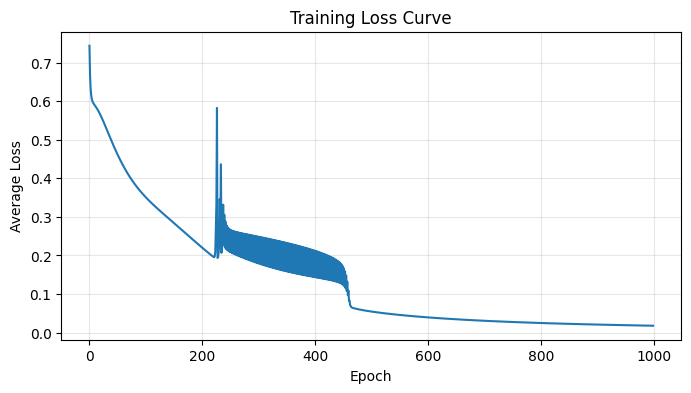

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.show()


**What to expect**: 
- Loss should **decrease** over epochs
- The network may or may not reach 100% accuracy — 2 hidden neurons is a small network
- If loss doesn't decrease at all, double-check your weight update signs (`w -= lr * gradient`, not `+=`)


Task 6: Observation Questions (0.5 points)

Answer the following questions in **this Markdown cell** (2–3 sentences each):

**(a)** Look at the printed σ'(z₁) and σ'(z₂) values from Task 4. Which neuron has the smaller derivative? What problem does this illustrate, and what activation function would fix it?

**Your answer (a)**:

Between the two neurons in task4:  
σ'(3) = 0.0452  
σ'(1) = 0.1966  
Neuron 1 is the smallest derivative.   
This is the vanishing gradient problem, which is when the pre activation value of z is far from 0.  
the sigmoid saturates and the derivative of it becomes smaller, which is what causes the gradient signal to keep shrnking during the back propagation.  
The weights update veruy slow.   
To fix this problem we would use an ReLU activation function, f(z) = max(0, z).  
its dreivative is a constant 1 for all positive inputs and does not continue to shrink down to 0.  


**(b)** Look at the loss curve from Task 5. Does the loss decrease smoothly or fluctuate? Did the network reach 100% accuracy on the 10 students? If not, why might a 2-hidden-neuron network struggle?

**Your answer (b)**:

The loss curve doesnt decrease smoothly.  
From 0.7 to 0.2, It starts off with a very sharp decrease, then continues to decrease steeply.  
Then a little after 200, at 0.2 it has a very sharp spike up all the way back up to 0.6.  
It continutes to decrease but with sharp spikes and oscillations until 450.   
At 450 is decreases a little less sharp down to from 0.2 to 0.7, and then continues to decrease smoothing until the end of the curve.  
The network did reach 100% for the 10 students by the end.  
A 2 hidden neuron can struggle because it has a higher limit compared to using more complext models..


---

## Grading Reference

| Task | Points | What We Check |
|---|---|---|
| Task 1: Sigmoid + derivative | 0.5 | Print output matches expected values |
| Task 2: Forward pass | 1.0 | Correct intermediate values; 10/10 accuracy with lecture weights |
| Task 3: Loss function | 0.5 | Loss values positive; Student F loss ≈ 0.4086 |
| Task 4: Backward pass | 1.5 | Gradient values match expected output for Student F |
| Task 5: Training loop | 1.0 | Loss curve decreases; final accuracy printed |
| Task 6: Observations | 0.5 | Answers demonstrate understanding |
| **Total** | **5.0** | |
